---
title: Lennard Jones Assignment
authors: gvarnavides
date: 2026-05-01
---

So far in the course we have focused on non-interacting systems.
In contrast, real systems consist of many particles that interact with one another.
As a first step in this direction, we will investigate the classical thermodynamics and statistical physics of a diatomic molecule, or dimer, whose atoms interact via the Lennard Jones potential, and analyze its continuum of microstates.

### Lennard Jones Potential

The Lennard Jones potential is a model for a particle's potential energy when it is separated from another particle. 
The model is simple -- particles attract each other when they are far apart and repel when they are very near.
All of the physics and its consequences derive from the shape of the potential:
- When the distance is small, the potential energy decreases with increasing distance.
  The force is positive and repulsive because force is minus the gradient of potential energy.
- When the distance is large, the potential energy slope is positive and so the force is negative: the particles attract.

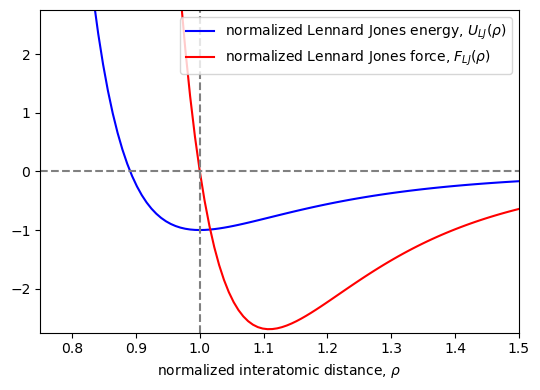

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.interpolate as sci

def normalized_lj_potential(rho):
    rho_inverse_6 = rho**(-6)
    potential = rho_inverse_6**2 - 2* rho_inverse_6
    return potential

def normalized_lj_force(rho):
    rho_inverse_6 = rho**(-6)
    force = 12.0 * (rho_inverse_6**2 - rho_inverse_6) / rho
    return force

rho = np.linspace(0.75,1.5,100)
lj_energy = normalized_lj_potential(rho)
lj_force = normalized_lj_force(rho)

fig, ax = plt.subplots(figsize=(5.5,4))
ax.plot(rho,lj_energy,color='blue',label=r'normalized Lennard Jones energy, $U_{LJ}(\rho)$')
ax.plot(rho,lj_force,color='red',label=r'normalized Lennard Jones force, $F_{LJ}(\rho)$')
ax.hlines([0],0.75,1.5,linestyles='dashed',color='gray')
ax.vlines(1.0,-2.75,2.75,linestyles='dashed',color='gray')
ax.set(
    xlim=[0.75,1.5],
    ylim=[-2.75,2.75],
    xlabel=r"normalized interatomic distance, $\rho$",
)
ax.legend()
fig.tight_layout()

We work with a non-dimensional form of the Lennard–Jones potential, where distances are scaled by the equilibrium separation, $\rho = r/r_{\min}$, and energies by the well depth, $\tilde{U} = U / |U_{\min}|$.
In these units, the potential has its minimum at $\rho = 1$ with energy $-1$, allowing us to focus on the general behavior rather than material-specific parameters.

The Lennard–Jones potential is commonly written as a combination of a short-range repulsive and long-range attractive term:
- A repulsive term that diverges as $r \to 0$
- An attractive term that decays as $r \to \infty$

$$
U(r) = \frac{a}{r^{12}} + \frac{b}{r^6},
$$

where $a$ and $b$ are material-dependent parameters.

To study the general behavior of this class of potentials, we introduce dimensionless variables:
- $\rho = r / r_{\min}$ (distance scaled by the equilibrium separation)
- $\tilde{U} = U / |U_{\min}|$ (energy scaled by the well depth)

In these units, the potential takes the universal form
$$
\tilde{U}(\rho) = \frac{1}{\rho^{12}} - \frac{2}{\rho^6},
$$
which has its minimum at $\rho = 1$ with $\tilde{U} = -1$.

### Velocity Verlet Integration

We are interested in capturing the dynamics of a Lennard-Jones dimer evolving at constant energy, i.e. forming a micro-canonical ensemble.
To do so, we need to integrate the classical equations of motion (EOM) using a symplectic (energy-conserving) integrator.


A simple and widely used symplectic integrator, is given by the leap-frog or [Velocity Verlet](wiki:Verlet_integration#Velocity_Verlet) method, which updates position and momentum in a staggered way, which helps maintain good energy conservation over long times:

The algorithm advances the system from time step $n$ to $n+1$ via:
$$
\begin{aligned}
        p_{n+1/2} &= p_n       + \frac{dt}{2} \, F(q_n) \\
        q_{n+1}   &= q_n       + dt  \,   p_{n+1/2} \\
        p_{n+1}   &= p_{n+1/2} + \frac{dt}{2} \, F(q_{n+1})
\end{aligned}
$$

where $q_n$ and $p_n$ are the position and momentum at time step $n$, and $F(q) = -\partial U / \partial q$ is the force.

You can use the provided [source-code](./lj-dimer-source-code) to integrate the EOM of a displaced dimer, where the particles are interacting with an arbirtary force function:

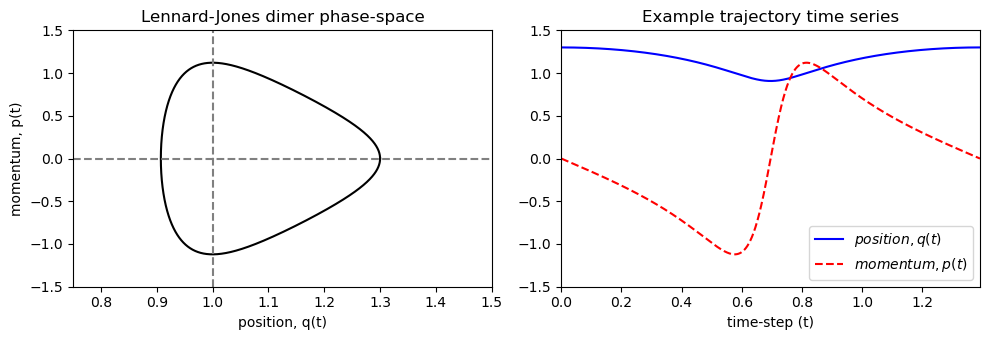

In [97]:
#| label: lj_example_trajectory
from lj_dimer import velocity_verlet_integrator

trajectory_positions,trajectory_momenta, trajectory_time = velocity_verlet_integrator(
    initial_position=1.3,
    force_function=normalized_lj_force,
)

fig,axs = plt.subplots(1,2,figsize=(10,3.5))
axs[0].plot(trajectory_positions,trajectory_momenta,color='k')
axs[0].set(
    xlabel='position, q(t)',
    ylabel='momentum, p(t)',
    xlim=[0.75,1.5],
    ylim=[-1.5,1.5],
    title="Lennard-Jones dimer phase-space"
)
axs[0].hlines(0,0.75,1.5,linestyles='dashed',color='gray')
axs[0].vlines(1,-1.5,1.5,linestyles='dashed',color='gray')
axs[1].plot(trajectory_time,trajectory_positions,color='blue',label=r'$position, q(t)$')
axs[1].plot(trajectory_time,trajectory_momenta,color='red',linestyle='dashed',label=r'$momentum, p(t)$')
axs[1].legend()
axs[1].set(
    xlabel='time-step (t)',
    xlim=[0,trajectory_time[-1]],
    ylim=[-1.5,1.5],
    title="Example trajectory time series"
)
fig.tight_layout()

### Part 1a: Energy Conservation

Using the provided code, evolve the displaced Lennard–Jones dimer in time to obtain a periodic orbit.

- Compute and plot the total energy as a function of time, and verify that it is conserved.
- Repeat the simulation for different time-steps $dt$, and quantify how the energy conservation (e.g., drift or fluctuations) depends on $dt$.

In [98]:
# calculate total energy
def total_energy(q,p,potential): # q = position, p = momentum, potential =  force function
        E = p**2/2 +potential(q)
        return E


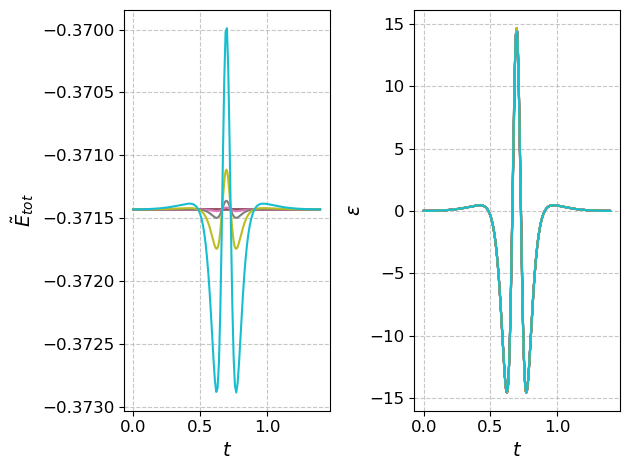

In [99]:
q0 = 1.3 ## Dimensionless
p0 = 0
n = 10
dt = np.logspace(-5,-2,n) # timesteps that will be used

E0 = total_energy(q0,p0,normalized_lj_potential) # The total energy

for i in range(0,n): # calculate the error for each initial position
    q,p,t = velocity_verlet_integrator(initial_position=q0,force_function=normalized_lj_force,dt=dt[i])
    E_tot = total_energy(q,p,normalized_lj_potential)
    error = E_tot-E0
    plt.subplot(121)
    plt.plot(t,E_tot,label='E_tot dt= % .6f'%dt[i])
    plt.subplot(122)
    plt.plot(t,error/dt[i]**2,label='error dt= % .6f'%dt[i])

# plotting some code
plt.subplot(121)
plt.xlabel(r'$t$', fontsize=14)
plt.ylabel(r'$\tilde{E}_{tot}$', fontsize=14)
# plt.xlim(0,2.5)
# plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()



plt.subplot(122)
plt.xlabel(r'$t$', fontsize=14)
plt.ylabel(r'$\epsilon$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()


plt.savefig("Img/1a/timestep.png")
plt.show()

In the left plot it can be seen that there is a clear dependance of the total energy on the used timestep dt. It can be seen that this error seems to be the same shape for different values of dt. To investigate this further the error was calculated and the right plot was made. This plot shows a rescaled error that is calculated as follows: $errorrescaled = \frac{H(t)-H(0)}{dt^2}$. Here it can be seen that all the Hamiltonian's follow the same formula H(t) = H(0) + dt^2*f(t). These terms of the second order are exactly the terms that are neglected in calculating the velocity in the velocity Verlet algorithm, They go by the name shadow Hamiltonian's [reputable source].

### Part 1b: Periodic Orbits

Using the provided code, compute periodic orbits of the Lennard–Jones dimer and visualize them in phase space $(q(t), p(t))$.

Construct $N = 100$ bound orbits by choosing different initial displacements $q_0$ (with initial momentum set to zero), and for each case evolve the system over one period.

Do this in two ways:
- Choose $q_0$ values that are evenly spaced in position (distance).
- Choose $q_0$ values such that the corresponding total energies are evenly spaced (you will need to determine the appropriate $q_0$ values to achieve this).

For each case:
- Compute the trajectories $(q(t), p(t))$.
- Plot all orbits together in a single phase-space portrait, coloring each orbit by its total energy.

#### Case 1: q0 evenly spaced in position (distance)

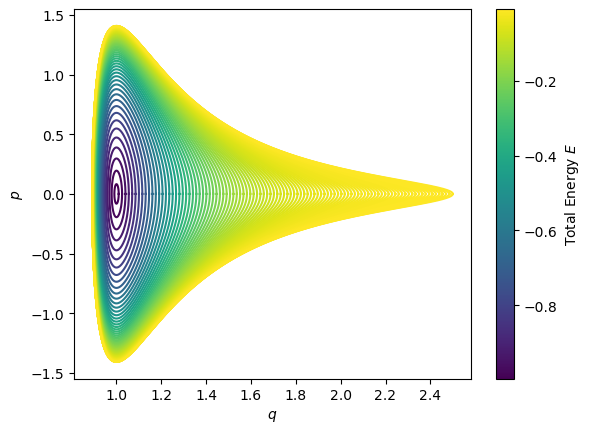

In [100]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

N = 100
q0_array = np.linspace(1.01,2.5,N) # N number of evenlyspaced initial positions
U0_array = total_energy(q0_array,0,normalized_lj_potential)

cmap = cm.viridis # create basic colormap
norm = mcolors.Normalize(vmin=np.min(U0_array), vmax=np.max(U0_array))

for i in range(N): # Loop over all initial conditions
    q0 = q0_array[i]
    A = velocity_verlet_integrator(initial_position=q0,force_function=normalized_lj_force)
    if type(A) != tuple: # Ensure that no type error is raised
        print("Initial position q0 = %.1f Does not yield a valid state"%q0)
    else:
        q,p,t = A
        orbit_color = cmap(norm(U0_array[i]))
        plt.plot(q, p, color=orbit_color)



# Plotting a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Required by Matplotlib to draw the colorbar
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Total Energy $E$')

# some plotting code
plt.xlabel(r'$q$')
plt.ylabel(r'$p$')
plt.savefig("Img/1b/q,p diagram different evenly spaced q0's.png")

#### Case 2: q0 corresponding energie evenly spaced

In [101]:
eps = 1e-3 # the minimum acuracy of the initial positions

# define a help potential for the Newton Rhapsum method of rootfinding
def root_potential(x,U):
    return normalized_lj_potential(x)-U

# Define a function the preforms the Newton Rhapsum method
def Newtonmethod(x_1,U_current):
    error=10
    while error>eps:
        x_2=x_1 - (root_potential(x_1,U_current)/-normalized_lj_force(x_1))
        error=np.abs(x_2-x_1)
        x_1=x_2
    return(x_1)

In [102]:
q0_min, q0_max = 1.01,2.5 # Define minimum and maximum initial positions
U_min = normalized_lj_potential(q0_min)
U_max = normalized_lj_potential(q0_max)
U_array = np.linspace(U_min,U_max,N)
print(U_array)
q0_array = np.zeros(N)
q0_array[0] = q0_min

## calculate all initial positions
for i in range(1,N):
    U = U_array[i]
    q0_expected = q0_array[i-1]
    q0_array[i] = Newtonmethod(q0_expected,U)

[-0.99664125 -0.98665674 -0.97667223 -0.96668773 -0.95670322 -0.94671872
 -0.93673421 -0.92674971 -0.9167652  -0.9067807  -0.89679619 -0.88681169
 -0.87682718 -0.86684268 -0.85685817 -0.84687367 -0.83688916 -0.82690466
 -0.81692015 -0.80693564 -0.79695114 -0.78696663 -0.77698213 -0.76699762
 -0.75701312 -0.74702861 -0.73704411 -0.7270596  -0.7170751  -0.70709059
 -0.69710609 -0.68712158 -0.67713708 -0.66715257 -0.65716807 -0.64718356
 -0.63719906 -0.62721455 -0.61723004 -0.60724554 -0.59726103 -0.58727653
 -0.57729202 -0.56730752 -0.55732301 -0.54733851 -0.537354   -0.5273695
 -0.51738499 -0.50740049 -0.49741598 -0.48743148 -0.47744697 -0.46746247
 -0.45747796 -0.44749345 -0.43750895 -0.42752444 -0.41753994 -0.40755543
 -0.39757093 -0.38758642 -0.37760192 -0.36761741 -0.35763291 -0.3476484
 -0.3376639  -0.32767939 -0.31769489 -0.30771038 -0.29772588 -0.28774137
 -0.27775687 -0.26777236 -0.25778785 -0.24780335 -0.23781884 -0.22783434
 -0.21784983 -0.20786533 -0.19788082 -0.18789632 -0.1

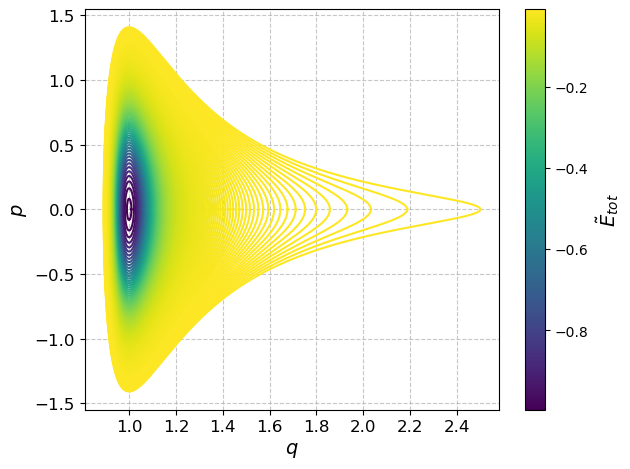

In [103]:
# Calculate all positions and momenta
q_matrix = np.zeros([N,int(2e5)])
p_matrix = np.zeros([N,int(2e5)])
t_matrix = np.zeros([N])

cmap = cm.viridis # create basic colormap
norm = mcolors.Normalize(vmin=np.min(U_array), vmax=np.max(U_array))

for i in range(N):
    q0 = q0_array[i]
    A = velocity_verlet_integrator(initial_position=q0,force_function=normalized_lj_force)
    if type(A) != tuple:
        print("Initial position q0 = %.1f Does not yield a valid state"%q0)
    else:
        q,p,t = A
        a = len(t)
        q_matrix[i,:a] = q
        p_matrix[i,:a] = p
        t_matrix[i] = t[-1]
        orbit_color = cmap(norm(U0_array[i]))
        plt.plot(q, p, color=orbit_color)

# Plotting a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Required by Matplotlib to draw the colorbar
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label(r'$\tilde{E}_{tot}$', fontsize=14)

# Some plotting code
plt.xlabel(r"$q$", fontsize=14)
plt.ylabel(r"$p$", fontsize=14)
plt.tight_layout()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("Img/1b/q,p diagram different q0's at equal energies.png")

### Part 1c: Microcanonical Ensemble

Each periodic orbit corresponds to a continuous set of microstates at a fixed total energy.
The number of accessible microstates (i.e. the _multiplicity_) can be obtained, starting from the area enclosed by the orbit in phase space.

More precisely, define
$$
J(E) = \frac{1}{2\pi} \oint p \, dq
$$
which is proportional to the area enclosed by the closed orbit in $(q,p)$ space.

The multiplicity is then given by
$$
\Omega(E) = \frac{dJ}{dE}.
$$

- Using the orbits constructed above with initial conditions equispaced in energy, compute and plot $J(E)$ numerically by estimating the area enclosed by each orbit in phase space.
  - _Hint:_ treat each orbit as a closed polygon in $(q,p)$ and use the Shoelace formula to compute its area.
- Compute and plot the multiplicity $\Omega(E)$ by numerically differentiating $J(E)$ with respect to $E$.
  - _Hint:_ you may find `scipy.interpolate.CubicSpline` useful for obtaining a smooth derivative.
- Compute and plot the microcanonical entropy $S(E) = \log \Omega(E)$.
- Validate that the orbit period satisfies $T(E) = 2\pi \frac{dJ}{dE},$ by comparing the measured period of each orbit to the derivative of $J(E)$.

##### Estimating $J(E)$

In [104]:
#Shoelace method
###(https://stackoverflow.com/questions/41077185/fastest-way-to-shoelace-formula)

def shoelace(x,y):
    #np.roll to get the next value in the array, including the first value at the end
    S1 = np.sum(x*np.roll(y,-1))
    S2 = np.sum(y*np.roll(x,-1))

    area = .5*np.abs(S1 - S2)

    return area

#Sanity check 2x2 square
A= np.array([0,2,2,0])
B= np.array([0,0,2,2])

print(shoelace(A,B))

4.0


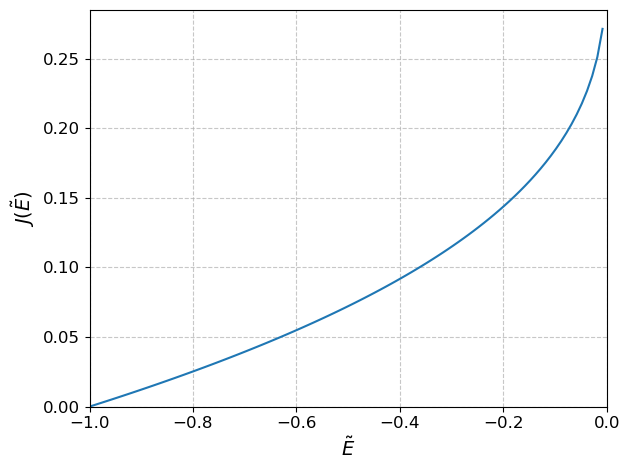

In [105]:
def getting_areas(q,p):
    #Filtering out zeros
    N = np.count_nonzero(q)
    q = q[:N]
    p = p[:N]

    return shoelace(q,p)

#Amount of areas as output voor elke p0
areas = np.zeros(len(q0_array))
energies = np.zeros(len(q0_array))

#Bereken voor elke p0 wat de area is en de total energy
for i in np.arange(len(q0_array)):
    areas[i] = getting_areas(q_matrix[i,:], p_matrix[i,:]) 
    energies[i] = total_energy(q_matrix[i,0],p_matrix[i,0],normalized_lj_potential)

J_E = areas/(2*np.pi)

plt.plot(energies, J_E)
plt.xlabel(r'$\tilde{E}$', fontsize=14)
plt.ylabel(r'$J (\tilde{E})$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-1,0)
plt.ylim(0)
plt.tight_layout()
plt.savefig("img/1c/action integral J(E).png")
plt.show()

##### Computing $\Omega(E)$

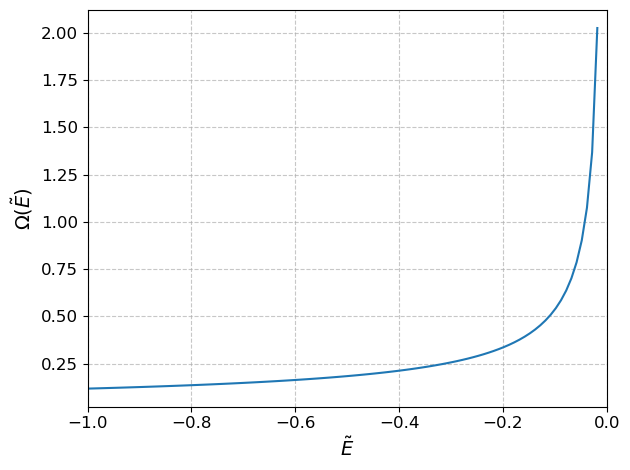

In [106]:
omega = np.diff(J_E, n=1)/np.diff(energies, n=1)
CS = sci.CubicSpline(energies[:-1],omega)

plt.plot(energies[:-1],CS(energies[:-1]))
plt.xlabel(r'$\tilde{E}$', fontsize=14)
plt.ylabel(r'$\Omega (\tilde{E})$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-1,0)
plt.tight_layout()
plt.savefig("img/1c/Multiplicity omega(E).png")
plt.show()

##### Computing $S(E)$

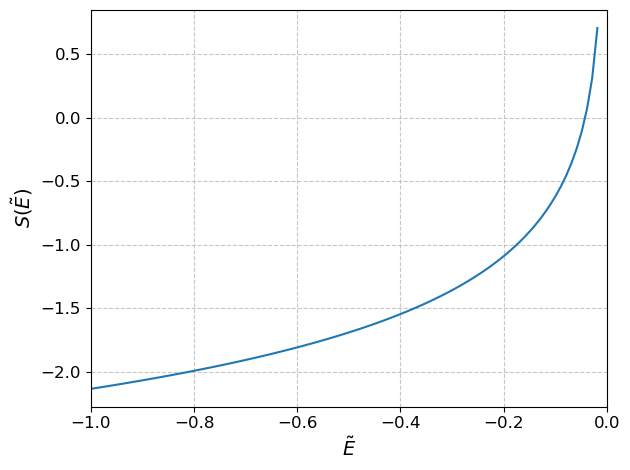

In [107]:
plt.plot(energies[0:-1], np.log(omega))
plt.xlabel(r'$\tilde{E}$', fontsize=14)
plt.ylabel(r'$S (\tilde{E})$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-1,0)
plt.tight_layout()
plt.savefig("img/1c/microcan entropy S(E).png")
plt.show()

##### Computing $T(E)$

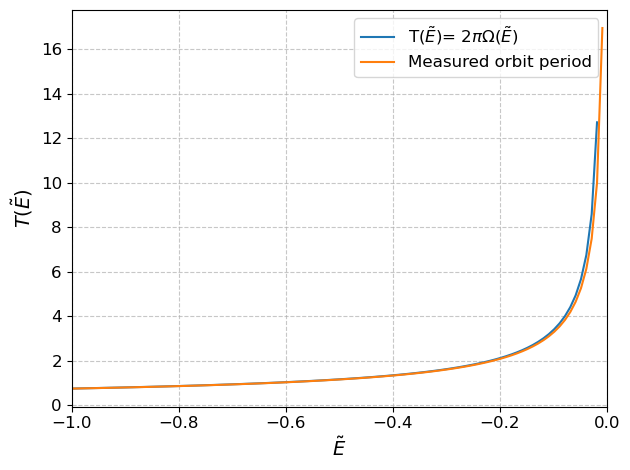

In [108]:
T = 2*np.pi*omega

plt.plot(energies[:-1],2*np.pi*CS(energies[:-1]), label=r"T($\tilde{E}$)= 2$\pi\Omega(\tilde{E})$")
plt.plot(energies, t_matrix, label="Measured orbit period")
plt.xlabel(r'$\tilde{E}$', fontsize=14)
plt.ylabel(r'$T (\tilde{E})$', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-1,0)
plt.tight_layout()
plt.savefig("img/1c/T(E).png")
plt.show()

### Part 1d: Canonical Ensemble

In the canonical ensemble, the partition function is given by
$$
Z(\beta) = \int \Omega(E)\, e^{-\beta E} \, dE,
$$
where $\beta = 1/(k_B T)$ and $\Omega(E)$ is the multiplicity computed previously.

All thermodynamic quantities can be derived from $Z(\beta)$.
- Compute $Z(\beta)$ numerically using your results for $\Omega(E)$.  
- Use it to compute the internal energy $U = \langle E \rangle$ and the heat capacity $C$.
  - Plot $U$ and $C$ as a function of $k_B T$.

Nog even controleren maar wikipedia zegt dat de dimensionless temperatuur gegeven wordt door
$T_{dimensionles} = k_b *$ nog werk te doen.
$\frac{U}{k_b*T} = $
Nog even uitvogelen wat de fysische Temperatuur is.
https://en.wikipedia.org/wiki/Lennard-Jones_potential#Dimensionless_(reduced_units)

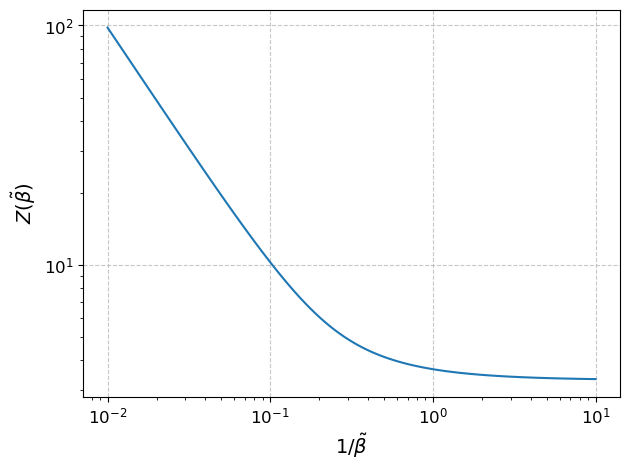

In [109]:
E = energies[:-1]
T = np.geomspace(0.01,10,N) # with T the dimensionlis Temperature
beta = 1/T
Z_bound = np.zeros(N)

for i in range(N):
    dZ = omega * np.e**(-beta[i]*E)
    Z_bound[i] = np.sum(dZ) # Calculate Z for this beta

# plot This from
plt.plot(T, np.log(Z_bound))
plt.xlabel(r'$1/\tilde{\beta}$', fontsize=14)
plt.ylabel(r'$Z(\tilde{\beta})$', fontsize=14)
plt.yscale("log")
plt.xscale("log")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("img/1d/Z(beta).png")
plt.show()

Average energy = -dln(Z)/dB

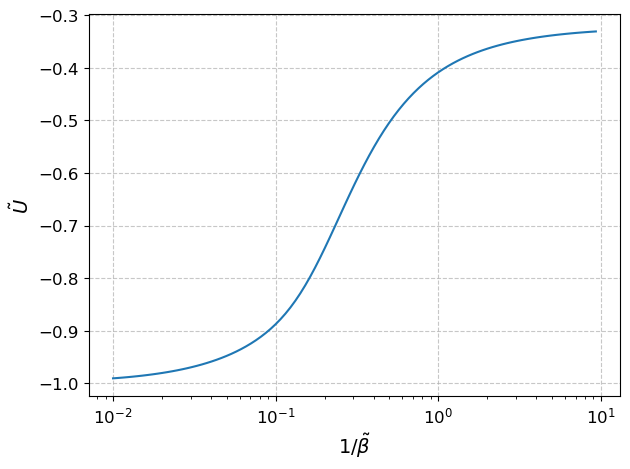

In [110]:
dlnZ_bound = np.diff(np.log(Z_bound), n=1)
dbeta = np.diff(beta, n=1)

U = -dlnZ_bound/dbeta
plt.plot(1/beta[:-1], U)

plt.xlabel(r'$1/\tilde{\beta}$', fontsize=14)
plt.ylabel(r'$\tilde{U}$', fontsize=14)
plt.xscale("log")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("img/1d/U(beta).png")
plt.show()

Heat capacity at constant volume.

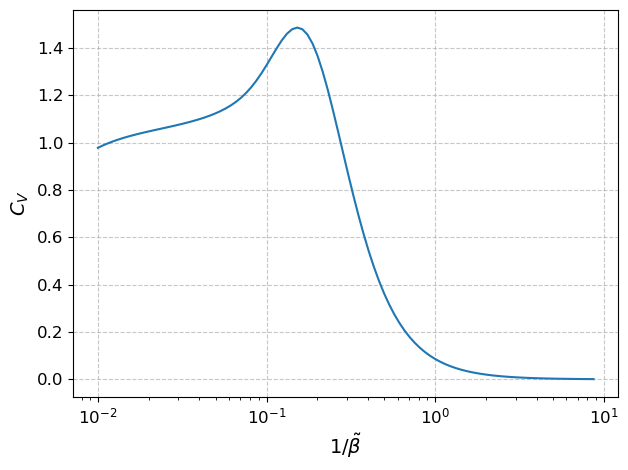

In [111]:
C_v = np.diff(U,n=1)/np.diff(T[:-1],n=1) # calculate heat capacity

#some plotting code
plt.plot(T[:-2], C_v)
plt.xlabel(r'$1/\tilde{\beta}$', fontsize=14)
plt.ylabel(r'$C_V$', fontsize=14)

plt.xscale("log")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("img/1d/CV(T)).png")
plt.show()

### Part 1e: Unbound States

The heat capacity approaching zero at high temperatures is a consequence of restricting to bound states ($E < 0$).
For $E > 0$, the Lennard–Jones potential describes unbound states, where the dimer dissociates and the two particles behave as free particles ($q \to \infty$).

To include these states, we model the relative motion as a free particle in a 1D box of length $L$, with partition function
$$
Z_{\mathrm{free}}(\beta) = \frac{L}{\sqrt{2\pi \beta}}.
$$

_Recall:_ we work in natural units, so constants such as Planck’s constant from your lecture notes do not appear above.

The total partition function is then the sum of the bound and free contributions:
$$
Z_{\mathrm{total}}(\beta) = Z_{\mathrm{bound}}(\beta) + Z_{\mathrm{free}}(\beta).
$$

- Repeat the calculations of the internal energy $U$ and heat capacity $C$, now using $Z_{\mathrm{total}}(\beta)$ with $L = 10$.
- Plot the heat capacity for several values of $L$, and comment on how the result depends on the box size.
- Explain the physical meaning of the high-temperature limit in this extended model.

In [112]:
L = 10

Z_free = L/np.sqrt(2*np.pi*beta)

Z_tot = Z_bound+Z_free

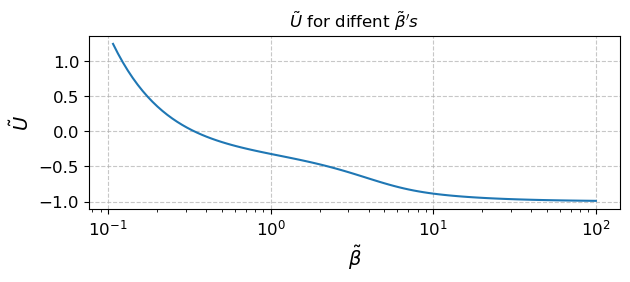

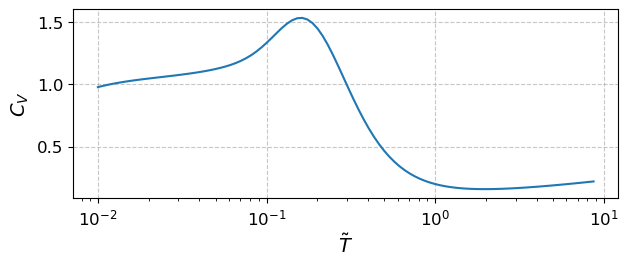

In [113]:
dlnZ_tot = np.diff(np.log(Z_tot), n=1)
dbeta = np.diff(beta, n=1)

U = -dlnZ_tot/dbeta
plt.subplot(2,1,1)

plt.plot(beta[:-1], U)
plt.xlabel(r'$\tilde{\beta}$', fontsize=14)
plt.ylabel(r'$\tilde{U}$', fontsize=14)
plt.title(r"$\tilde{U}$ for diffent $\tilde{\beta}'s$")
plt.xscale("log")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

plt.subplot(2,1,2)
C_v = np.diff(U,n=1)/np.diff(T[:-1],n=1) # calculate heat capacity

#some plotting code
plt.plot(T[:-2], C_v)
plt.xlabel(r'$\tilde{T}$', fontsize=14)
plt.ylabel(r'$C_V$', fontsize=14)
plt.xscale("log")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

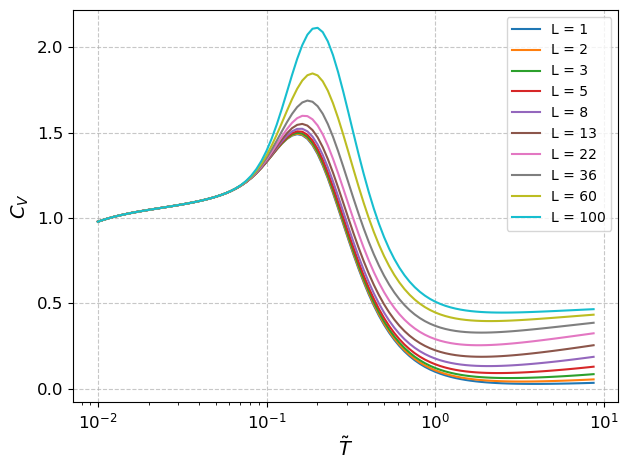

In [114]:
L_array = np.geomspace(1,100,10)

for i in range(10):
    Z_free = L_array[i]/np.sqrt(2*np.pi*beta)
    Z_tot = Z_bound+Z_free
    dlnZ_tot = np.diff(np.log(Z_tot), n=1)
    dbeta = np.diff(beta, n=1)
    U = -dlnZ_tot/dbeta
    C_v = np.diff(U,n=1)/np.diff(T[:-1],n=1)
    plt.plot(T[:-2], C_v,label="L = %.f"%L_array[i])

plt.xlabel(r'$\tilde{T}$', fontsize=14)
plt.ylabel(r'$C_V$', fontsize=14)
plt.xscale("log")
plt.legend()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("img/1e/Cv different L's.png")
plt.show()

### Part 1f: Harmonic Approximation

At low energies, the dimer oscillates near the minimum of the potential and can be well approximated by a harmonic oscillator:
$$
U_{\mathrm{HO}}(\rho) = -1 + 36(\rho - 1)^2 + O\!\left((\rho - 1)^3\right).
$$

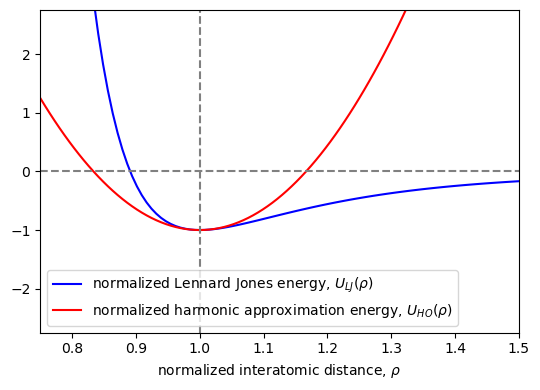

In [115]:
rho = np.linspace(0.75,1.5,100)
lj_energy = normalized_lj_potential(rho)
harmonic_energy = 36*(rho - 1)**2 - 1

fig, ax = plt.subplots(figsize=(5.5,4))
ax.plot(rho,lj_energy,color='blue',label=r'normalized Lennard Jones energy, $U_{LJ}(\rho)$')
ax.plot(rho,harmonic_energy,color='red',label=r'normalized harmonic approximation energy, $U_{HO}(\rho)$')
ax.hlines([0],0.75,1.5,linestyles='dashed',color='gray')
ax.vlines(1.0,-2.75,2.75,linestyles='dashed',color='gray')
ax.set(
    xlim=[0.75,1.5],
    ylim=[-2.75,2.75],
    xlabel=r"normalized interatomic distance, $\rho$",
)
ax.legend()
fig.tight_layout()

For a harmonic oscillator, several properties simplify analytically:

- The motion is perfectly periodic, and the orbits in $(q,p)$ are ellipses.
- The period of the motion is independent of the energy.
  - As a result, the area enclosed by the orbit grows linearly with energy, so the multiplicity is constant and the entropy does not depend on energy.
- The heat capacity is constant and equal to $k_B$ at all temperatures.

Your task is to validate these results numerically by repeating the previous analysis, replacing the Lennard–Jones potential with the harmonic approximation:
- Compute phase-space orbits $(q(t), p(t))$ and verify that they are elliptical and that the period is independent of energy.
- Compute the enclosed area for each orbit, and verify that it grows linearly with energy, and that the multiplicity is constant.
- Compute the entropy and confirm that it is constant.
- Compute the partition function, internal energy, and heat capacity, and verify that $C \approx k_B$ for all temperatures.

# code for parts 1-3 of 1f. 
for the last part we had to slightly alter the code from the beginning in order to get  more points. 

## phase space plots

### even in position

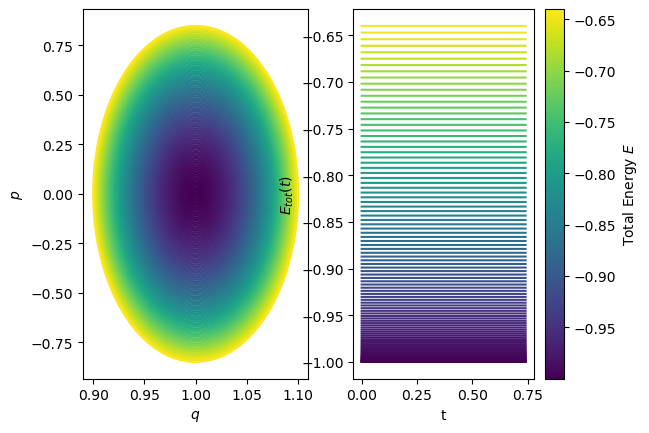

In [116]:

N=100
dt=np.logspace(-5,1,N)
p0=0
q0=1.3



def harmonic_energy(rho): #using here that the q=rho-1. 
    return 36*(rho-1)**2-1

def harmonic_force(rho):
    return -72*(rho-1)


q0_arrayh = np.linspace(1.001,1.1,N) # N number of evenlyspaced initial positions
U0_arrayh = total_energy(q0_arrayh,0,harmonic_energy)

cmap = cm.viridis # create basic colormap
norm = mcolors.Normalize(vmin=np.min(U0_arrayh), vmax=np.max(U0_arrayh))


for i in range(0,N): #for testing different initial positions
    q0 = q0_arrayh[i]
    A = velocity_verlet_integrator(initial_position=q0,force_function=harmonic_force,dt=1e-4)
    if type(A) != tuple:
        print("Initial position q0 = %.1f Does not yield a valid state"%q0)
    else:
        qh,ph,th = A
        Etot=harmonic_energy(qh)+ph**2/2
        orbit_colorh = cmap(norm(U0_arrayh[i]))
        plt.subplot(121)
        plt.plot(qh, ph, color=orbit_colorh)
        plt.xlabel(r"$q$")
        plt.ylabel(r"$p$")
        
        #plt.plot(qh,ph,label="q0 = %.2f"%q0)

    qh=np.array(qh)
    ph=np.array(ph)
    Uh=harmonic_energy(qh)
    Etoth=np.array(Etot)
    plt.subplot(122)
    plt.plot(th,Etoth,color=orbit_colorh)
    plt.xlabel("t")
    plt.ylabel(r"$E_{tot}(t)$")
   


    import matplotlib.cm as cm
import matplotlib.colors as mcolors





# Plotting a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Required by Matplotlib to draw the colorbar
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Total Energy $E$')

   

#it is clear from the plots that the period is independent of the total energy

### even in time

[-0.999964 -0.996328 -0.992692 -0.989056 -0.98542  -0.981784 -0.978148
 -0.974512 -0.970876 -0.96724  -0.963604 -0.959968 -0.956332 -0.952696
 -0.94906  -0.945424 -0.941788 -0.938152 -0.934516 -0.93088  -0.927244
 -0.923608 -0.919972 -0.916336 -0.9127   -0.909064 -0.905428 -0.901792
 -0.898156 -0.89452  -0.890884 -0.887248 -0.883612 -0.879976 -0.87634
 -0.872704 -0.869068 -0.865432 -0.861796 -0.85816  -0.854524 -0.850888
 -0.847252 -0.843616 -0.83998  -0.836344 -0.832708 -0.829072 -0.825436
 -0.8218   -0.818164 -0.814528 -0.810892 -0.807256 -0.80362  -0.799984
 -0.796348 -0.792712 -0.789076 -0.78544  -0.781804 -0.778168 -0.774532
 -0.770896 -0.76726  -0.763624 -0.759988 -0.756352 -0.752716 -0.74908
 -0.745444 -0.741808 -0.738172 -0.734536 -0.7309   -0.727264 -0.723628
 -0.719992 -0.716356 -0.71272  -0.709084 -0.705448 -0.701812 -0.698176
 -0.69454  -0.690904 -0.687268 -0.683632 -0.679996 -0.67636  -0.672724
 -0.669088 -0.665452 -0.661816 -0.65818  -0.654544 -0.650908 -0.647272
 -0.6436

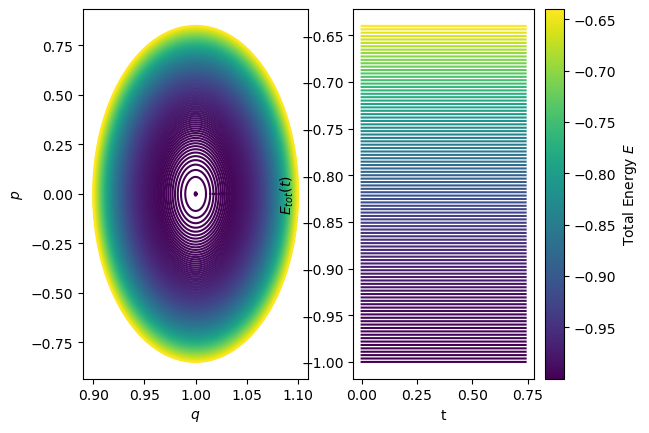

In [117]:
eps = 1e-3 # the minimum acuracy of the initial positions

# define a help potential for the Newton Rhapsum method of rootfinding
def root_potentialh(x,U):
    return harmonic_energy(x)-U

# Define a function the preforms the Newton Rhapsum method
def Newtonmethodh(x_1,U_current):
    error=10
    while error>eps:
        x_2=x_1 - (root_potentialh(x_1,U_current)/-harmonic_force(x_1))
        error=np.abs(x_2-x_1)
        x_1=x_2
    return(x_1)

q0_min, q0_max = 1.001,1.1 # Define minimum and maximum initial positions
U_min = harmonic_energy(q0_min)
U_max = harmonic_energy(q0_max)
U_array = np.linspace(U_min,U_max,N)
print(U_array)
q0_array = np.zeros(N)
q0_array[0] = q0_min

## calculate all initial positions
for i in range(1,N):
    U = U_array[i]
    q0_expected = q0_array[i-1]
    q0_array[i] = Newtonmethodh(q0_expected,U)

    # Calculate all positions and momenta
q_matrixh = np.zeros([N,int(2e5)])
p_matrixh= np.zeros([N,int(2e5)])
t_matrixh = np.zeros([N])


for i in range(N):
    q0 = q0_array[i]
    A = velocity_verlet_integrator(initial_position=q0,force_function=harmonic_force)
    if type(A) != tuple:
        print("Initial position q0 = %.1f Does not yield a valid state"%q0)
    else:
        qh,ph,th = A
        a = len(th)
        Etoth=harmonic_energy(qh)+ph**2/2
        q_matrixh[i,:a] = qh
        p_matrixh[i,:a] = ph
        t_matrixh[i] = th[-1]
        orbit_colorh = cmap(norm(U0_arrayh[i]))
        plt.subplot(121)
        plt.plot(qh, ph, color=orbit_colorh)
        plt.xlabel(r"$q$")
        plt.ylabel(r"$p$")
        plt.subplot(122)
        plt.plot(th, Etoth,color=orbit_colorh)
        plt.xlabel("t")
        plt.ylabel(r"$E_{tot}(t)$")



# Plotting a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Required by Matplotlib to draw the colorbar

cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Total Energy $E$')


# Some plotting code


## Enclosed Area J(E)

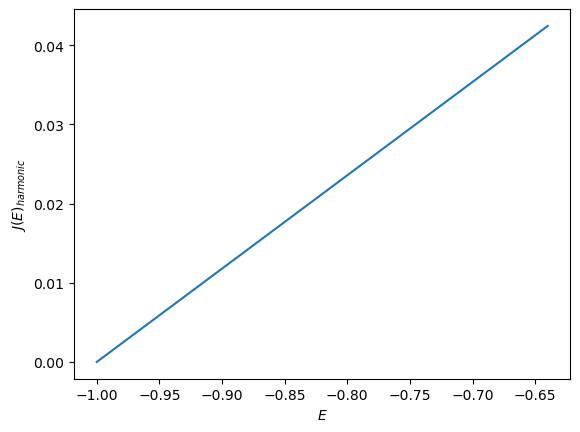

In [118]:
#Amount of areas as output voor elke p0
areash = np.zeros(len(q0_array))
energiesh = np.zeros(len(q0_array))

#Bereken voor elke p0 wat de area is en de total energy
for i in np.arange(len(q0_array)):
    areash[i] = getting_areas(q_matrixh[i,:], p_matrixh[i,:])
    energiesh[i] = total_energy(q_matrixh[i,0],p_matrixh[i,0],harmonic_energy)

J_Eh = areash/(2*np.pi)

plt.plot(energiesh, J_Eh)
plt.xlabel(r'$E$')
plt.ylabel(r'$J (E)_{harmonic}$')
plt.show()

## multiplicity $\Omega(E)$

[0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.1178

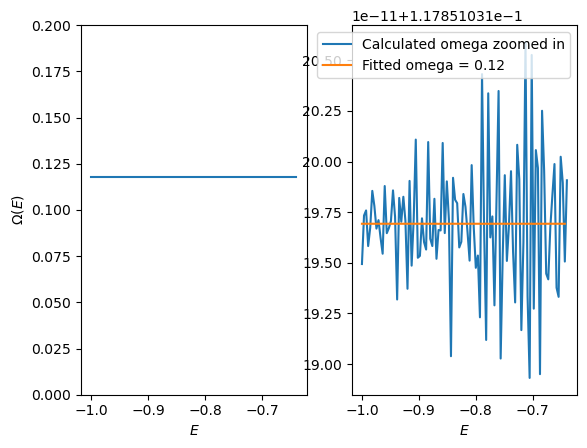

In [119]:
#multiplicity 

import scipy.interpolate as interpolate
Eh=energiesh

J_Eh_smoothed = interpolate.CubicSpline(Eh, J_Eh) #cubic spline to smoothen function- spoiler alert- did not work well enough.

x = np.linspace(min(Eh), max(Eh), N)
y = J_Eh_smoothed(x)


omegah = J_Eh_smoothed.derivative()(x) #derivative of j(E) in order to get the multiplicity
plt.subplot(121)
plt.ylim(0,0.2)
plt.plot(x,omegah,label="Calculated omega zoomed out")
#plt.plot(energiesh,J_Eh,"k.",label="data")

plt.xlabel(r'$E$')
plt.ylabel(r'$\Omega(E)$')
plt.subplot(122)
plt.plot(x,omegah,label="Calculated omega zoomed in")
plt.xlabel(r'$E$')

#plt.title("Calculated $\Omega$(E)$ using the smoothed J(E)")

# do a function fit to get omega in order to get a better derivative. 
def func_fit(E, a, b):
    return a *E+b

from scipy.optimize import curve_fit
popt, pcov = curve_fit(func_fit, Eh, J_Eh)
a_fit, b_fit = popt
JE_fit=func_fit(x, a_fit, b_fit)



#plotting the fit on top of what was done previously.
omegah_fit = np.diff(JE_fit, n=1)/np.diff(x, n=1)

plt.plot(x[:-1],omegah_fit,label=f'Fitted omega = {a_fit:.2f}')
plt.legend()
print(omegah_fit) #printing just to see the values of fitted omega- this is constant

## testing if T is independent of energy

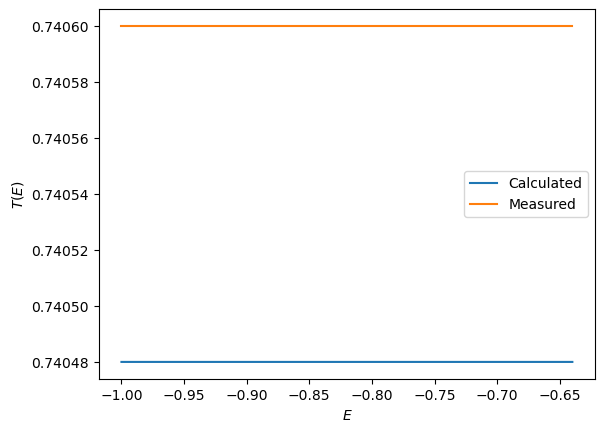

In [120]:
Th = 2*np.pi*omegah

plt.plot(energiesh, 2*np.pi*omegah, label="Calculated")
plt.plot(energiesh, t_matrixh, label="Measured") #we can see a small difference here which is due to numerical noise. however it is very clear that the period is independent of energy.
plt.xlabel(r'$E$')
plt.ylabel(r'$T (E)$')
plt.legend()
plt.show()

## Entropy S(E)

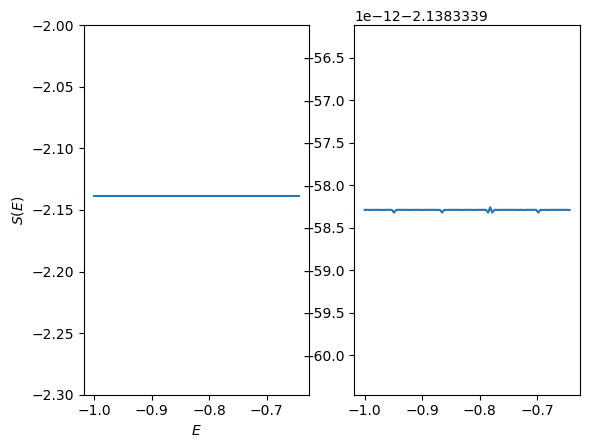

In [121]:
plt.subplot(121)
plt.plot(energiesh[:-1], np.log(omegah_fit)) #entropy is just the natural log of multiplicity. again one zoomed out and one zoomed in. using fitted function for omega- which is constant
plt.xlabel(r'$E$')
plt.ylabel(r'$S(E)$')
plt.ylim(-2.3,-2)
plt.subplot(122)
plt.plot(energiesh[:-1], np.log(omegah_fit))





#again the same issue with noise when zoomed in really far. order magnitude e-13

Sh= np.log(a_fit)


# code for part 4 of 1f. 
note that part of the previous code just gets repeated here with a different value for N

## repeat code

[-9.99964000e-01  1.91895488e+00  4.83787377e+00  7.75679265e+00
  1.06757115e+01  1.35946304e+01  1.65135493e+01  1.94324682e+01
  2.23513871e+01  2.52703059e+01  2.81892248e+01  3.11081437e+01
  3.40270626e+01  3.69459815e+01  3.98649004e+01  4.27838192e+01
  4.57027381e+01  4.86216570e+01  5.15405759e+01  5.44594948e+01
  5.73784137e+01  6.02973325e+01  6.32162514e+01  6.61351703e+01
  6.90540892e+01  7.19730081e+01  7.48919270e+01  7.78108458e+01
  8.07297647e+01  8.36486836e+01  8.65676025e+01  8.94865214e+01
  9.24054403e+01  9.53243591e+01  9.82432780e+01  1.01162197e+02
  1.04081116e+02  1.07000035e+02  1.09918954e+02  1.12837872e+02
  1.15756791e+02  1.18675710e+02  1.21594629e+02  1.24513548e+02
  1.27432467e+02  1.30351386e+02  1.33270305e+02  1.36189223e+02
  1.39108142e+02  1.42027061e+02  1.44945980e+02  1.47864899e+02
  1.50783818e+02  1.53702737e+02  1.56621656e+02  1.59540575e+02
  1.62459493e+02  1.65378412e+02  1.68297331e+02  1.71216250e+02
  1.74135169e+02  1.77054

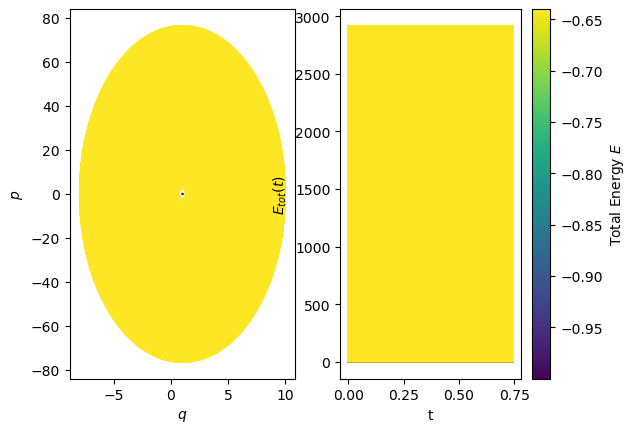

In [122]:
N=1000
# dt=np.logspace(-5,1,N)
p0=0
q0=1.3



def harmonic_energy(rho): #using here that the q=rho-1.
    return 36*(rho-1)**2-1

def harmonic_force(rho):
    return -72*(rho-1)
eps = 1e-3 # the minimum acuracy of the initial positions

# define a help potential for the Newton Rhapsum method of rootfinding
def root_potentialh(x,U):
    return harmonic_energy(x)-U

# Define a function the preforms the Newton Rhapsum method
def Newtonmethodh(x_1,U_current):
    error=10
    while error>eps:
        x_2=x_1 - (root_potentialh(x_1,U_current)/-harmonic_force(x_1))
        error=np.abs(x_2-x_1)
        x_1=x_2
    return(x_1)

q0_min, q0_max = 1.001,10 # Define minimum and maximum initial positions
U_min = harmonic_energy(q0_min)
U_max = harmonic_energy(q0_max)
U_array = np.linspace(U_min,U_max,N)
print(U_array)
q0_array = np.zeros(N)
q0_array[0] = q0_min

## calculate all initial positions
for i in range(1,N):
    U = U_array[i]
    q0_expected = q0_array[i-1]
    q0_array[i] = Newtonmethodh(q0_expected,U)

    # Calculate all positions and momenta
q_matrixh = np.zeros([N,int(2e5)])
p_matrixh= np.zeros([N,int(2e5)])
t_matrixh = np.zeros([N])


for i in range(N):
    q0 = q0_array[i]
    A = velocity_verlet_integrator(initial_position=q0,force_function=harmonic_force)
    if type(A) != tuple:
        print("Initial position q0 = %.1f Does not yield a valid state"%q0)
    else:
        qh,ph,th = A
        a = len(th)
        Etoth=harmonic_energy(qh)+ph**2/2
        q_matrixh[i,:a] = qh
        p_matrixh[i,:a] = ph
        t_matrixh[i] = th[-1]
        orbit_colorh = cmap(norm(U_array[i]))
        plt.subplot(121)
        plt.plot(qh, ph, color=orbit_colorh)
        plt.xlabel(r"$q$")
        plt.ylabel(r"$p$")
        plt.subplot(122)
        plt.plot(th, Etoth,color=orbit_colorh)
        plt.xlabel("t")
        plt.ylabel(r"$E_{tot}(t)$")



# Plotting a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Required by Matplotlib to draw the colorbar

cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Total Energy $E$')

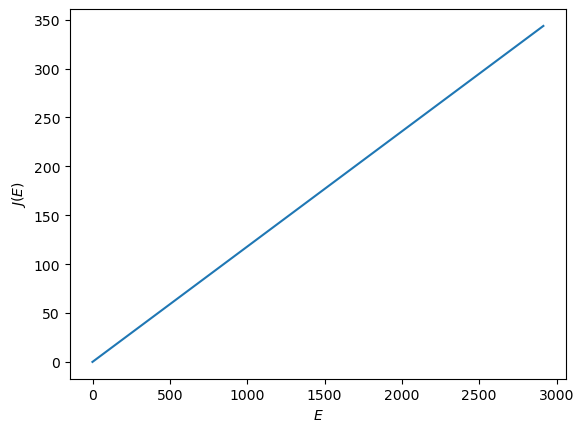

In [123]:
#Amount of areas as output voor elke p0
areash = np.zeros(N)
energiesh = np.zeros(N)

#Bereken voor elke p0 wat de area is en de total energy
for i in np.arange(N):
    areash[i] = getting_areas(q_matrixh[i,:], p_matrixh[i,:]) 
    energiesh[i] = total_energy(q_matrixh[i,0],p_matrixh[i,0],harmonic_energy)

J_Eh = areash/(2*np.pi)

plt.plot(energiesh, J_Eh)
plt.xlabel(r'$E$')
plt.ylabel(r'$J(E)$')
plt.show()

[0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103
 0.11785103 0.11785103 0.11785103 0.11785103 0.11785103 0.1178

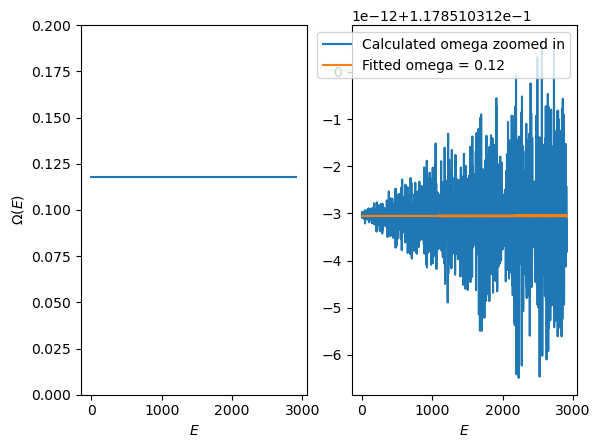

In [124]:
#multiplicity 

import scipy.interpolate as interpolate
Eh=energiesh

J_Eh_smoothed = interpolate.CubicSpline(Eh, J_Eh) #cubic spline to smoothen function- spoiler alert- did not work well enough.

x = np.linspace(min(Eh), max(Eh), N)
y = J_Eh_smoothed(x)


omegah = J_Eh_smoothed.derivative()(x) #derivative of j(E) in order to get the multiplicity

plt.subplot(121)
plt.ylim(0,0.2)
plt.plot(x,omegah,label="Calculated omega zoomed out")
#plt.plot(energiesh,J_Eh,"k.",label="data")

plt.xlabel(r'$E$')
plt.ylabel(r'$\Omega(E)$')
plt.subplot(122)
plt.plot(x,omegah,label="Calculated omega zoomed in")
plt.xlabel(r'$E$')

#plt.title("Calculated $\Omega$(E)$ using the smoothed J(E)")

# do a function fit to get omega in order to get a better derivative. 
def func_fit(E, a, b):
    return a *E+b

from scipy.optimize import curve_fit
popt, pcov = curve_fit(func_fit, Eh, J_Eh)
a_fit, b_fit = popt
JE_fit=func_fit(x, a_fit, b_fit)



#plotting the fit on top of what was done previously.
omegah_fit = np.diff(JE_fit, n=1)/np.diff(x, n=1)

plt.plot(x[:-1],omegah_fit,label=f'Fitted omega = {a_fit:.2f}')
plt.legend()
print(omegah_fit) #printing just to see the values of fitted omega- this is constant

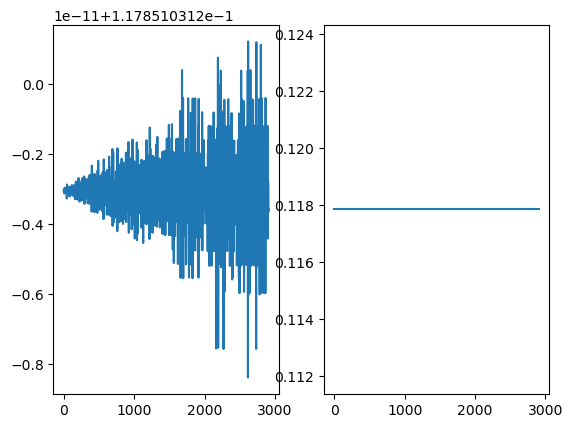

In [125]:
# DAnielle
omegah = np.diff(J_Eh,n=1)/np.diff(Eh,n=1)
plt.subplot(121)
plt.plot(Eh[:-1],omegah)
omegah_fit = np.zeros(N-1) + np.mean(omegah) # to reduce noise when taking derivatieve
Sh = np.log(omegah_fit)
plt.subplot(122)
plt.plot(Eh[:-1],omegah_fit)

## relevant new bits
we assumed that the multiplicity is constant for the following analyisis so it could be taken outside of the integral 

## partition function $Z(\beta)$

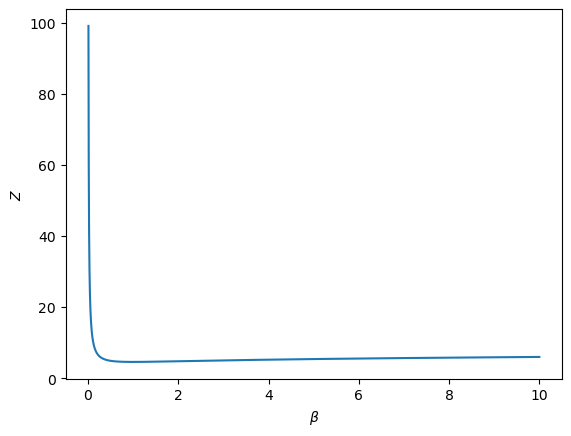

In [126]:
# new partition
K = 300000
E_dense = np.linspace(-1,1000,K)
T = np.geomspace(0.01,10,N) # with T the dimensionlis Temperature
beta = 1/T
Z = np.zeros(N)
# print(omegah_fit)

for i in range(N):
    dZ = np.mean(omegah) * np.e**(-beta[i]*E_dense[:])
    Z[i] = np.sum(dZ) # Calculate Z for this beta

# plot This from
plt.plot(T, np.log(Z)) #note that we are plottingthe log of Z because that makes it easier to seee the funcition shape
plt.xlabel(r'$\beta$')
plt.ylabel(r'$Z$')
# plt.yscale("log")

plt.show()

## internal energy U(T)

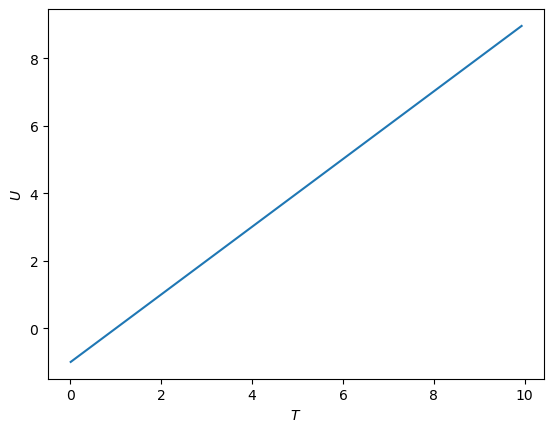

In [127]:
# Danielle Internal energy
dlnZ = np.diff(np.log(Z), n=1)
dbeta = np.diff(beta, n=1)

U = -dlnZ/dbeta
plt.plot(T[:-1], U)

plt.xlabel(r'$T$')
plt.ylabel(r'$U$')

# plt.xscale("log")
plt.show()

## Heat capacity $C_v(T)$

not quite constant however this is an error introduced by the step size of numerical integration for the partition function(more about this in our report)

Text(0, 0.5, '$C_V$')

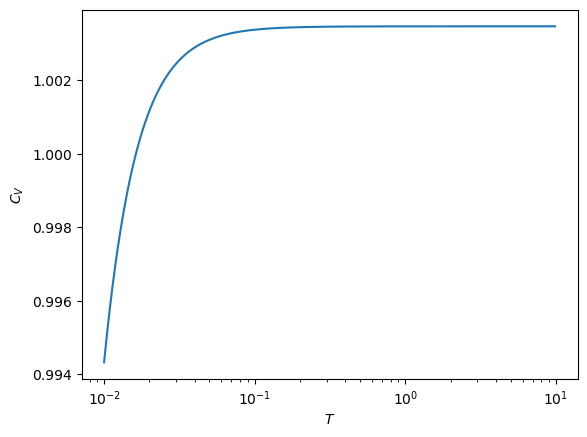

In [128]:
C_v = np.diff(U,n=1)/np.diff(T[:-1],n=1) # calculate heat capacity

#some plotting code
plt.plot(T[:-2], C_v)
plt.xlabel(r'$T$')
plt.xscale("log")
plt.ylabel(r'$C_V$')